# Steam Review Analysis

## 1. Introduction & Objective

### 1.1. Background

This project explores a sample of the Steam Reviews Dataset containing information about reviewers, their game playtime, review activity, review feedback, and the text of their written reviews.<br>
<br>
The dataset contains both structured variables, such as playtime and the number of games owned, and unstructured textual data in the form of user reviews. This makes it possible to investigate both user behavior and review content.<br>
<br>
You can find out more information about the Steam Reviews Dataset here:
https://www.kaggle.com/datasets/forgemaster/steam-reviews-dataset?resource=download

### 1.2. Objective

The main objective of this project is to investigate which characteristics of Steam reviews and reviewers are associated with positive game recommendations. In addition, the project explores whether review text provides useful information for predicting whether a user recommends a game.<br>
<br>
Because this analysis uses a sample of the full Steam Reviews Dataset, the findings should be interpreted as observations about the analyzed sample rather than conclusions about all Steam users or reviews.

### 1.3. Research Questions

**Primary Research Question**<br>
<br>
1. Which features are associated with whether a review recommends a game?<br>
<br>
**Secondary Research Questions**<br>
<br>
2. What are the main characteristics and quality issues of the Steam Reviews dataset?<br>
3. What patterns and differences can be observed between positive and negative recommendations?<br>
4. How effectively can the selected features be used to predict whether a review recommends a game?<br>

### 1.4. Analytical Approach

To investigate these questions, the project will proceed through data quality assessment, exploratory data analysis, feature engineering, text analysis, predictive modeling, and model evaluation. The results will then be interpreted in the context of the research questions, with particular attention to the limitations of the sample and the available variables.

## 2. Loading the Data

First we import the required libraries:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns

We'll now load the dataset:

In [2]:
df = pd.read_csv("../data/reviews-13500-13537.csv")

Let's make sure it got loaded correctly:

In [3]:
df.shape

(8086, 13)

Let's also take a look at the first few rows of the dataset and view its statistic overview:

In [4]:
df.head(5)

,steamid,appid,voted_up,votes_up,votes_funny,weighted_vote_score,playtime_forever,playtime_at_review,num_games_owned,num_reviews,review,unix_timestamp_created,unix_timestamp_updated
0,76561198414702117,598060,False,0,1,0.424996,368,192,188,14,Game is amazing. But there is a camera sway wh...,1618673751,1618673751
1,76561198422616434,598060,True,0,0,0.000000,1175,1133,39,5,YES.,1618588463,1618588463
2,76561198001462345,598060,True,0,0,0.000000,63,63,324,2,Very Cool concept but with the platforming and...,1618373962,1618373962
3,76561198008037092,598060,True,0,0,0.000000,473,452,431,16,"Yup, pretty hard. I like it. I hope I play it ...",1618337175,1618337175
4,76561198105898959,598060,True,0,0,0.000000,3139,2699,67,1,Wonderful game to just turn off your mind and ...,1618193343,1618193343


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8086 entries, 0 to 8085
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   steamid                 8086 non-null   int64  
 1   appid                   8086 non-null   int64  
 2   voted_up                8086 non-null   bool   
 3   votes_up                8086 non-null   int64  
 4   votes_funny             8086 non-null   int64  
 5   weighted_vote_score     8086 non-null   float64
 6   playtime_forever        8086 non-null   int64  
 7   playtime_at_review      8086 non-null   int64  
 8   num_games_owned         8086 non-null   int64  
 9   num_reviews             8086 non-null   int64  
 10  review                  8070 non-null   str    
 11  unix_timestamp_created  8086 non-null   int64  
 12  unix_timestamp_updated  8086 non-null   int64  
dtypes: bool(1), float64(1), int64(10), str(1)
memory usage: 766.1 KB


## 3. Data Understanding & Data Quality

### 3.1. Understanding the Variables

| **Column** | **Meaning** | **Type/Role**
| :--- | :--- | :--- |
| `steamid`| The Steam ID of the user who wrote this review | Identifier |
| `appid` | The ID of the app being reviewed | Identifier |
| `voted_up` | Whether the review showed a positive attitude towards the game. **True** means the review was positive | Target Variable |
| `votes_up` | The number of other users who found this review helpful | Numerical |
| `votes_funny` | The number of other users who found this review funny | Numerical |
| `weighted_vote_score` | Helpfulness score, automatically calculated by Steam using its internal algorithm | Numerical |
| `playtime_forever` | How many hours the user who wrote this review had played this game when the dataset was created | Numerical |
| `playtime_at_review` | How many hours the user had played this game when writing the review | Numerical |
| `num_games_owned` | The number of games the user owns | Numerical |
| `num_reviews` | The number of reviews the user has written | Numerical |
| `review` | The text of the written review | **Text** |
| `unix_timestamp_created` | The date on which this review was created | Timestamp |
| `unix_timestamp_updated` | The date on which this review was last updated | Timestamp |

### 3.2. Data types and basic structure

In [6]:
df.shape

(8086, 13)

In [7]:
df.dtypes

steamid                     int64
appid                       int64
voted_up                     bool
votes_up                    int64
votes_funny                 int64
weighted_vote_score       float64
playtime_forever            int64
playtime_at_review          int64
num_games_owned             int64
num_reviews                 int64
review                        str
unix_timestamp_created      int64
unix_timestamp_updated      int64
dtype: object

The dataset contains 8086 rows and 13 columns. 11 columns are numerical, including 10 integer columns and 1 float column. 1 column, the `voted_up` column, is boolean. And 1 column, the `review` column, is text.

In [8]:
df.nunique()

steamid                   8042
appid                       12
voted_up                     2
votes_up                    89
votes_funny                 34
weighted_vote_score       2349
playtime_forever          3623
playtime_at_review        2608
num_games_owned           1185
num_reviews                282
review                    7823
unix_timestamp_created    8086
unix_timestamp_updated    8086
dtype: int64

In [9]:
df.describe()

,steamid,appid,votes_up,votes_funny,weighted_vote_score,playtime_forever,playtime_at_review,num_games_owned,num_reviews,unix_timestamp_created,unix_timestamp_updated
count,8.086000e+03,8086.000000,8086.000000,8086.000000,8086.000000,8086.000000,8086.000000,8086.000000,8086.000000,8.086000e+03,8.086000e+03
mean,7.656120e+16,598622.122186,2.424314,0.376700,0.223451,2795.494558,1393.070121,274.526960,25.050952,1.567183e+09,1.568417e+09
std,2.765839e+08,338.215292,12.078875,2.325907,0.259796,8303.102209,4352.532906,487.213087,89.577746,4.081779e+07,4.040761e+07
min,7.656120e+16,598060.000000,0.000000,0.000000,0.000000,5.000000,5.000000,0.000000,1.000000,1.487905e+09,1.487905e+09
25%,7.656120e+16,598330.000000,0.000000,0.000000,0.000000,350.000000,190.000000,54.000000,3.000000,1.531861e+09,1.533660e+09
50%,7.656120e+16,598700.000000,0.000000,0.000000,0.000000,869.000000,452.500000,138.000000,7.000000,1.580057e+09,1.581076e+09
75%,7.656120e+16,598980.000000,1.000000,0.000000,0.497512,2244.000000,1111.000000,309.000000,20.000000,1.605924e+09,1.606098e+09
max,7.656120e+16,598980.000000,545.000000,79.000000,0.941871,239974.000000,100120.000000,12696.000000,4137.000000,1.619058e+09,1.619058e+09


We have 8086 reviews but 8042 users, indicating that several users wrote multiple reviews in this sample. We can view the userid values of some users who wrote the most reviews in this sample:

In [10]:
df["steamid"].value_counts().head()

steamid
76561197965193437    3
76561197980787602    2
76561198045592963    2
76561198001558786    2
76561197993894575    2
Name: count, dtype: int64

The `appid` column only has 12 distinct values, while the dataset as a whole reportedly contains reviews of 8183 games. Since our sample is much smaller than the original dataset, we should be careful about making statements about "Steam games" in general just from observations taken from this sample.<br>
We can view the unique values in the column `appid` and their counts in our sample:

In [11]:
df["appid"].value_counts()

appid
598980    2341
598330    1892
598060    1097
598700    1055
598960     660
598810     528
598450     161
598470     115
598490      87
598690      70
598440      63
598070      17
Name: count, dtype: int64

The column `voted_up` has 2 distinct values, which is exactly what we would expect from a boolean column with only 2 possible values: True and False. However, we can't yet tell whether these values are balanced. Let's check it:

In [12]:
df["voted_up"].value_counts(normalize=True) * 100

voted_up
True     86.730151
False    13.269849
Name: proportion, dtype: float64

Approximately 86.73% of the observations in this sample has `voted_up`=True, which means our sample is highly skewed.

`votes_up` only has 89 distinct values even though there are 8086 rows in this dataset. The min value and the 25%  and 50% quartiles for this column are all 0, indicating that at least 50% of the reviews in this sample has no up vote. We can verify that here:

In [13]:
df["votes_up"].value_counts(normalize=True) * 100

votes_up
0      58.483799
1      17.214939
2       7.766510
3       4.044027
4       2.188969
         ...    
290     0.012367
75      0.012367
71      0.012367
73      0.012367
97      0.012367
Name: proportion, Length: 89, dtype: float64

Similarly, `votes_funny` only has 34 distinct values, and the min value and all 3 quartiles are 0, which means at least 75% of the reviews in our sample had no funny vote. The actual percentage turns out to be around 86.58%:

In [14]:
df["votes_funny"].value_counts(normalize=True).head() * 100

votes_funny
0    86.581746
1     8.372496
2     1.941628
3     0.939896
4     0.581252
Name: proportion, dtype: float64

`weighted_vote_score` has 2349 distinct values ranging from 0 to 0.941871. This variable has much more variation and can potentially be useful for analyzing review helpfulness.

`playtime_forever` and `playtime_at_review` also has 3623 and 2608 distinct values respectively. These two variables have great variation, with `playtime_at_review` potentially being more relevant to the research question.

`num_games_owned` has 1185 distinct values, while `num_reviews` only has 282 distinct values, with a maximum of 4,137 reviews written by a single user. This might be worth further investigation.

We have 7823 unique review texts but 8086 data rows, meaning there are 263 duplicated values in the `review` column. However, this doesn't necessarily mean there were duplicate observations, as two users can independently write a review like 'Good game' or 'YES'. We can look at that later.

Both timestamp columns has 8086 unique values corresponding to our 8086 data rows, which means all the reviews were written and last updated at different times compared to each other.

Let's take another look at the statistical summary of the numerical columns in the dataset:

In [15]:
df.describe()

,steamid,appid,votes_up,votes_funny,weighted_vote_score,playtime_forever,playtime_at_review,num_games_owned,num_reviews,unix_timestamp_created,unix_timestamp_updated
count,8.086000e+03,8086.000000,8086.000000,8086.000000,8086.000000,8086.000000,8086.000000,8086.000000,8086.000000,8.086000e+03,8.086000e+03
mean,7.656120e+16,598622.122186,2.424314,0.376700,0.223451,2795.494558,1393.070121,274.526960,25.050952,1.567183e+09,1.568417e+09
std,2.765839e+08,338.215292,12.078875,2.325907,0.259796,8303.102209,4352.532906,487.213087,89.577746,4.081779e+07,4.040761e+07
min,7.656120e+16,598060.000000,0.000000,0.000000,0.000000,5.000000,5.000000,0.000000,1.000000,1.487905e+09,1.487905e+09
25%,7.656120e+16,598330.000000,0.000000,0.000000,0.000000,350.000000,190.000000,54.000000,3.000000,1.531861e+09,1.533660e+09
50%,7.656120e+16,598700.000000,0.000000,0.000000,0.000000,869.000000,452.500000,138.000000,7.000000,1.580057e+09,1.581076e+09
75%,7.656120e+16,598980.000000,1.000000,0.000000,0.497512,2244.000000,1111.000000,309.000000,20.000000,1.605924e+09,1.606098e+09
max,7.656120e+16,598980.000000,545.000000,79.000000,0.941871,239974.000000,100120.000000,12696.000000,4137.000000,1.619058e+09,1.619058e+09


`playtime_forever` and `playtime_at_review` both have the mean more than 3 times higher than the median, suggesting that some users probably have much more playtime than others and are raising the average playtime.

`num_reviews` has a median of 7 but a much higher max value of 4137, possibly making the distribution of this variable highly right-skewed.

`votes_up` has a median of 0, a 75% quartile of 1, a mean of 2.42, and a max value of 545. This means that 50% of reviews have votes_up = 0, 75% of reviews have votes_up <= 1, but at least 1 review has votes_up = 545. This variable has a **right-skewed distribution.**
The same pattern can be seen in the `votes_funny` column, with a median of 0, a 75% quartile of 0, and a max value of 79.

`weighted_vote_score` has a mean value of 0, a median of 0, and a 75% quartile of 0.497512. 50% of the reviews has weighted_vote_score = 0, but 75% of the record has weighted_vote_score <= 0.497512, suggesting that the distribution of this variable might be right-skewed as well.

The mean, median, min and max values for `appid` are rather close and not particularly meaningful since this is an identifier, not a meaningful variable. The same goes for `steamid`.

`unix_timestamp_created` and `unix_timestamp_updated` are still numerical, which is why they appear in this statistical summary. We will need to convert them to DateTime format before investigating them.

Overall, we have learned that:
- Our sample has 8086 reviews and 8042 unique users but only **12 games.** This number of games is much smaller than the reported count for the original dataset as a whole, so we have to be cautious when making statements about Steam games in general.
- We have 7823 unique review texts.
- We do not have any obvious missing values in the numerical columns.
- Several numerical variables are strongly **right-skewed,** such as `num_reviews`, `votes_up` or `votes_funny`.
- `votes_up`, `votes_funny`, and `weighted_vote_score` contains many zero values. `playtime_forever`, `playtime_at_review`, and `num_review` have extreme values.
- Timestamps need conversion before they can be interpreted.
- `steamid` and `appid` are identifiers, not meaningful numerical measurements.
- Our target variable `voted_up` is also greatly skewed.

### 3.3. Data Quality Assessment

#### Missing values:

In [16]:
df.isna().sum()

steamid                    0
appid                      0
voted_up                   0
votes_up                   0
votes_funny                0
weighted_vote_score        0
playtime_forever           0
playtime_at_review         0
num_games_owned            0
num_reviews                0
review                    16
unix_timestamp_created     0
unix_timestamp_updated     0
dtype: int64

We only have 16 missing valies in the `review` column.

#### Duplicate Observations:

In [17]:
df.duplicated().sum()

np.int64(0)

We don't have any duplicated records, which is a good sign.

#### Invalid/unusual values:

##### Boolean column: `voted_up`

In [18]:
df["voted_up"].value_counts()

voted_up
True     7013
False    1073
Name: count, dtype: int64

We have no unusual or invalid values in the `voted_up` column since it consists entirely of True and False values.

##### Numerical variables

Let's check for negative values:

In [19]:
numeric_nonnegative = [
    "votes_up",
    "votes_funny",
    "playtime_forever",
    "playtime_at_review",
    "num_games_owned",
    "num_reviews"
]

for col in numeric_nonnegative:
    print(col, (df[col] < 0).sum())

votes_up 0
votes_funny 0
playtime_forever 0
playtime_at_review 0
num_games_owned 0
num_reviews 0


For the numerical columns that aren't supposed to be negative, we don't have any negative values.

Let's also check whether `playtime_at_review` exceeds `playtime_forever`, since the former should conceptually not surpass the latter:

In [20]:
(df["playtime_at_review"] > df["playtime_forever"]).sum()

np.int64(1)

Oh no! Let's check this anomalous record:

In [21]:
df.loc[
    df["playtime_at_review"] > df["playtime_forever"],
    [
        "steamid",
        "appid",
        "voted_up",
        "playtime_forever",
        "playtime_at_review",
        "review",
        "unix_timestamp_created",
        "unix_timestamp_updated"
    ]
]

,steamid,appid,voted_up,playtime_forever,playtime_at_review,review,unix_timestamp_created,unix_timestamp_updated
4653,76561198127270528,598810,True,150,183,very addictive,1609159372,1609159372


**Logical consistency:** One observation was identified where playtime_at_review (183 hours) exceeds playtime_forever (150 hours). This contradicts the expected relationship between the two variables. However, because this is a single observation and there is insufficient evidence to determine which value is incorrect, the observation is retained rather than arbitrarily modified or removed. It will be treated as a potential anomaly when analyzing playtime-related variables.

#### Target-variable distribution:

In [22]:
df['voted_up'].value_counts()

voted_up
True     7013
False    1073
Name: count, dtype: int64

As we've discussed above, our target variable `voted_up` in this sample is **highly skewed,** with approximately 86.73% of the records having voted_up = True.<br>
However, this bias is not necessarily a sampling problem. It might actually represent the overall trend, since it's not entirely impossible for a majority of Steam reviews to be positive.

#### Numerical-variable distribution:

In [23]:
df.describe()

,steamid,appid,votes_up,votes_funny,weighted_vote_score,playtime_forever,playtime_at_review,num_games_owned,num_reviews,unix_timestamp_created,unix_timestamp_updated
count,8.086000e+03,8086.000000,8086.000000,8086.000000,8086.000000,8086.000000,8086.000000,8086.000000,8086.000000,8.086000e+03,8.086000e+03
mean,7.656120e+16,598622.122186,2.424314,0.376700,0.223451,2795.494558,1393.070121,274.526960,25.050952,1.567183e+09,1.568417e+09
std,2.765839e+08,338.215292,12.078875,2.325907,0.259796,8303.102209,4352.532906,487.213087,89.577746,4.081779e+07,4.040761e+07
min,7.656120e+16,598060.000000,0.000000,0.000000,0.000000,5.000000,5.000000,0.000000,1.000000,1.487905e+09,1.487905e+09
25%,7.656120e+16,598330.000000,0.000000,0.000000,0.000000,350.000000,190.000000,54.000000,3.000000,1.531861e+09,1.533660e+09
50%,7.656120e+16,598700.000000,0.000000,0.000000,0.000000,869.000000,452.500000,138.000000,7.000000,1.580057e+09,1.581076e+09
75%,7.656120e+16,598980.000000,1.000000,0.000000,0.497512,2244.000000,1111.000000,309.000000,20.000000,1.605924e+09,1.606098e+09
max,7.656120e+16,598980.000000,545.000000,79.000000,0.941871,239974.000000,100120.000000,12696.000000,4137.000000,1.619058e+09,1.619058e+09


As we mentioned above, several numerical variables exhibit strong right-skewed distributions. For example, `playtime_forever` has a median of 869 minutes compared with a mean of 2,795 minutes, while `num_reviews` has a median of 7 compared with a mean of 25.1. This suggests that a relatively small number of highly active users or reviews may strongly influence the mean. These distributions will be examined visually during exploratory data analysis.

#### Timestamp validity:

First, let's check whether the timestamps are valid:

In [24]:
df["created_at"] = pd.to_datetime(
    df["unix_timestamp_created"],
    unit="s"
)

df["updated_at"] = pd.to_datetime(
    df["unix_timestamp_updated"],
    unit="s"
)

df[["created_at", "updated_at"]].describe()

,created_at,updated_at
count,8086,8086
mean,2019-08-30 16:32:57,2019-09-13 23:21:39
min,2017-02-24 03:00:18,2017-02-24 03:00:18
25%,2018-07-17 21:01:28,2018-08-07 16:41:18
50%,2020-01-26 16:42:54,2020-02-07 11:41:32
75%,2020-11-21 01:54:28,2020-11-23 02:23:30
max,2021-04-22 02:11:55,2021-04-22 02:11:55


In [25]:
print(df["created_at"].min(), df["created_at"].max())
print(df["updated_at"].min(), df["updated_at"].max())

2017-02-24 03:00:18 2021-04-22 02:11:55
2017-02-24 03:00:18 2021-04-22 02:11:55


In [26]:
(df["updated_at"] < df["created_at"]).sum()

np.int64(0)

The Unix timestamps were converted into datetime values for easier interpretation. The resulting dates fall within a plausible historical range, and no observations have an update timestamp earlier than their creation timestamp. Therefore, no obvious timestamp inconsistencies were detected.

#### Sample/representativeness considerations:

This analysis uses one file from the larger dataset. The sample contains 8,086 reviews across 12 games and hence should not automatically be assumed to represent the overall Steam review population. The results should therefore be interpreted as observations about this sample rather than definitive conclusions about all Steam users or games.

## 4. Exploratory Data Analysis

### 4.1. Distribution of Recommendations

Let's visualize the distribution:

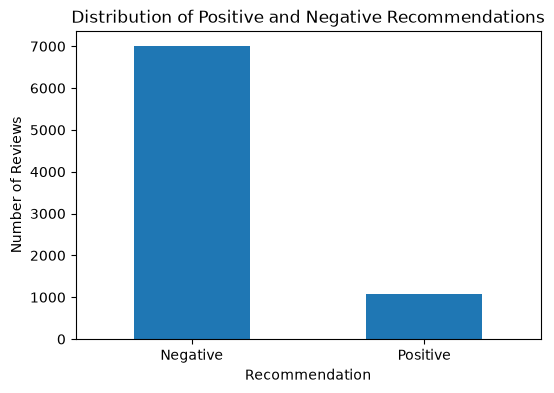

In [27]:
import matplotlib.pyplot as plt

recommendation_counts = df["voted_up"].value_counts()

plt.figure(figsize=(6, 4))
recommendation_counts.plot(kind="bar")

plt.title("Distribution of Positive and Negative Recommendations")
plt.xlabel("Recommendation")
plt.ylabel("Number of Reviews")
plt.xticks(
    ticks=[0, 1],
    labels=["Negative", "Positive"],
    rotation=0
)

plt.show()

Let's also calculate the percentages:

In [28]:
recommendation_percentages = (
    df["voted_up"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

recommendation_percentages

voted_up
True     86.73
False    13.27
Name: proportion, dtype: float64

As we have already noted, the target variable is **sustantially embalanced.**

### 4.2. Playtime

<Figure size 800x500 with 0 Axes>

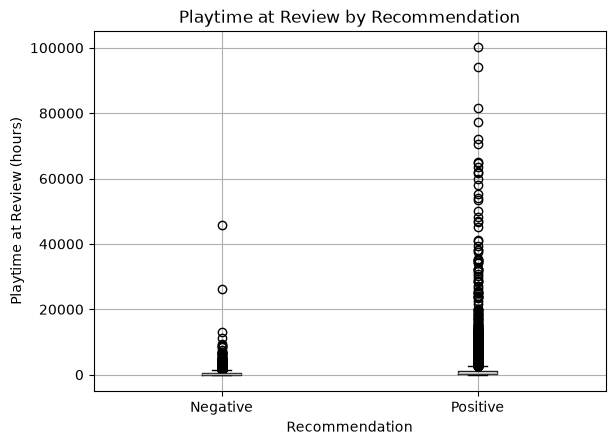

In [29]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column="playtime_at_review",
    by="voted_up"
)

plt.title("Playtime at Review by Recommendation")
plt.suptitle("")
plt.xlabel("Recommendation")
plt.ylabel("Playtime at Review (hours)")
plt.xticks(
    ticks=[1, 2],
    labels=["Negative", "Positive"]
)

plt.show()

Most values are squashed flat near zero because a few massive outliers stretch the y-axis up to 100,000 hours.<br>
Positive reviews have significantly more high-playtime outliers, indicating that players who spend thousands of hours on a game are almost exclusively giving positive reviews.<br>
This chart demonstrates why raw playtime is difficult to visualize with standard boxplots—the interquartile range (IQR) boxes are unreadable.

<Figure size 800x500 with 0 Axes>

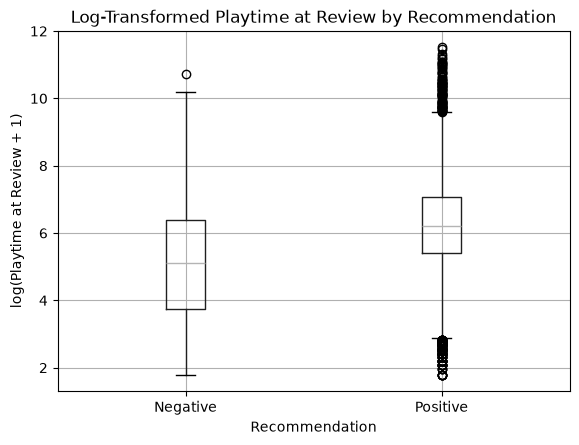

In [30]:
import numpy as np

df["log_playtime_at_review"] = np.log1p(df["playtime_at_review"])

plt.figure(figsize=(8, 5))

df.boxplot(
    column="log_playtime_at_review",
    by="voted_up"
)

plt.title("Log-Transformed Playtime at Review by Recommendation")
plt.suptitle("")
plt.xlabel("Recommendation")
plt.ylabel("log(Playtime at Review + 1)")
plt.xticks(
    ticks=[1, 2],
    labels=["Negative", "Positive"]
)

plt.show()

The horizontal line inside each box represents the median log-playtime. The Positive recommendation median (~6.2, which translates to $e^{6.2} - 1 \approx 492$ hours) is higher than the Negative recommendation median (~5.1, or $\approx 163$ hours).<br>
The middle 50% of positive reviewers consistently have higher playtime values compared to negative reviewers.<br>
The log transformation converts the highly skewed distribution into a near-normal distribution, making it easy to compare spreads and medians directly.

**Key Takeaways:**<br>
- Players who write positive reviews generally have substantially higher playtime at the time of writing than those leaving negative reviews.
- Players leaving negative reviews tend to do so much earlier in their play experience (lower median playtime and lower overall range).
- The np.log1p() transformation was necessary to handle the severe skewness and zero values, allowing for clear visual comparison across both recommendation types.

### 4.3. User Engagement

<Figure size 800x500 with 0 Axes>

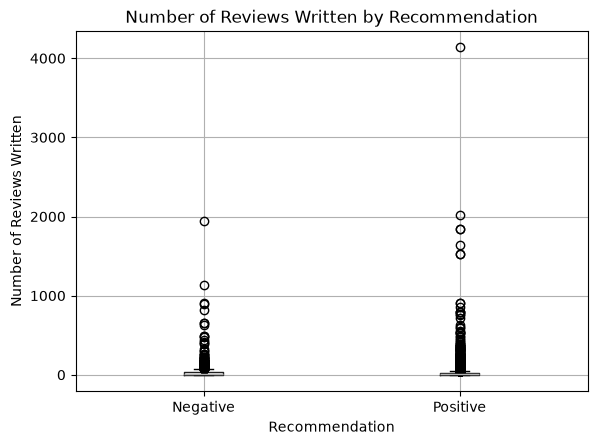

In [31]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column="num_reviews",
    by="voted_up"
)

plt.title("Number of Reviews Written by Recommendation")
plt.suptitle("")
plt.xlabel("Recommendation")
plt.ylabel("Number of Reviews Written")
plt.xticks(
    ticks=[1, 2],
    labels=["Negative", "Positive"]
)

plt.show()

Just like playtime, the majority of users write very few reviews (flattening the boxes near zero), while a tiny minority of "power reviewers" write thousands.<br>
Positive recommendations contain higher maximum outliers (reaching over 4,000 total reviews written by a single account), but the primary distribution remains completely obscured without the log scale.

<Figure size 800x500 with 0 Axes>

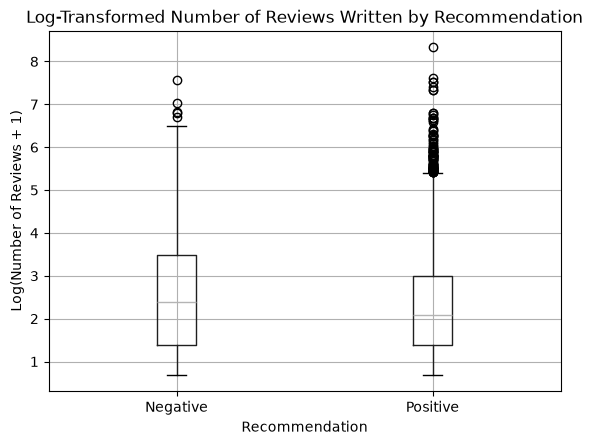

In [32]:
df["log_num_reviews"] = np.log1p(df["num_reviews"])

plt.figure(figsize=(8, 5))

df.boxplot(
    column="log_num_reviews",
    by="voted_up"
)

plt.title("Log-Transformed Number of Reviews Written by Recommendation")
plt.suptitle("")
plt.xlabel("Recommendation")
plt.ylabel("Log(Number of Reviews + 1)")
plt.xticks(
    ticks=[1, 2],
    labels=["Negative", "Positive"]
)

plt.show()

We can see that the median log value for Negative reviews (~2.4, or $\approx 10$ reviews) is actually slightly higher than for Positive reviews (~2.1, or $\approx 7$ reviews).<br>
Users who actively write more reviews overall on Steam seem slightly more inclined to leave negative feedback when they review a game, or at least have a higher baseline for criticism compared to casual reviewers.<br>
The Interquartile Ranges (the main boxes) heavily overlap between ~1.4 and ~3.5 on the log scale, meaning typical users leave a similar number of total reviews regardless of whether a specific review is positive or negative.

**Key Takeaways:**
- Unlike playtime (where high engagement correlates with positive sentiment), general reviewer prolificity (`num_reviews`) leans slightly toward negative reviews. Highly active community reviewers may be more critical.<br>
- Comparing both pairs of charts demonstrates that log transformations aren't just for cleaning up plots—they reveal hidden behavioral trends (like medians flipping or aligning) that raw scale outliers hide.

### 4.4. Compare Positive vs Negative Reviews

In [33]:
group_summary = df.groupby("voted_up")[
    [
        "playtime_at_review",
        "playtime_forever",
        "num_games_owned",
        "num_reviews",
        "votes_up",
        "votes_funny",
        "weighted_vote_score"
    ]
].median()

group_summary

,playtime_at_review,playtime_forever,num_games_owned,num_reviews,votes_up,votes_funny,weighted_vote_score
voted_up,,,,,,,
False,163.0,233.0,162.0,10.0,1.0,0.0,0.462471
True,499.0,960.0,134.0,7.0,0.0,0.0,0.000000


In the code snippet above, we used the median instead of the mean because our variables are heavily right-skewed. The mean can be heavily distorted by users with enormous playtime or thousands of reviews. The median gives us a much more representative "typical" user.<br>
From the table above, we can see that players with negative reviews have much less playtime both when writing reviews and when the dataset was created, corresponding to a worse experience. The former also own more games, write more reviews, and have more up votes. Most reviews, either positive or negative, seem to receive no funny votes. Negative reviews are perceived as more constructive, shown by a higher median helpfulness score (`weighted_vote_score`).

### 4.5. Review Text

In [34]:
df["review_length"] = df["review"].str.len()
df.groupby("voted_up")["review_length"].median()

voted_up
False    286.0
True     141.0
Name: review_length, dtype: float64

It can be seen that negative reviews are usually more lengthy than positive ones, indicated by the higher median length.

<Figure size 800x500 with 0 Axes>

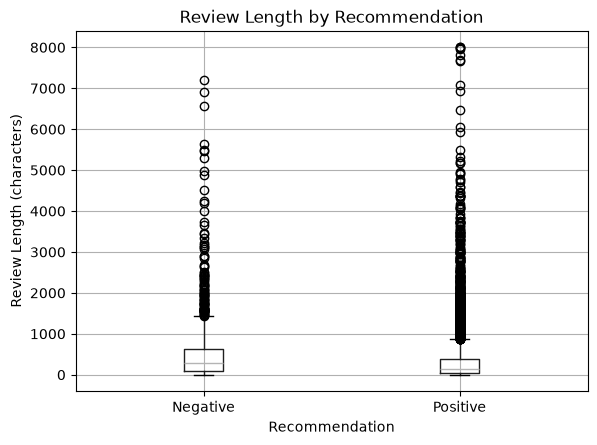

In [35]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column="review_length",
    by="voted_up"
)

plt.title("Review Length by Recommendation")
plt.suptitle("")
plt.xlabel("Recommendation")
plt.ylabel("Review Length (characters)")
plt.xticks(
    ticks=[1, 2],
    labels=["Negative", "Positive"]
)

plt.show()

We can see that the entire box for Negative reviews sits visibly higher than the box for Positive reviews. Both the median line (50th percentile) and the Interquartile Range (25th to 75th percentiles) are larger for negative feedback, showing that disgruntled players consistently write longer posts.<br>
While negative reviews are generally longer on average, Positive reviews contain higher absolute maximum outliers (reaching up to ~8,000 characters) and possibly more outliers. This likely represents dedicated fans writing massive, comprehensive guides or deeply detailed praise.<br>
Both distributions are heavily right-skewed, compressed toward lower character counts with a dense trail of outliers extending upward.

### 4.6. Temporal Patterns

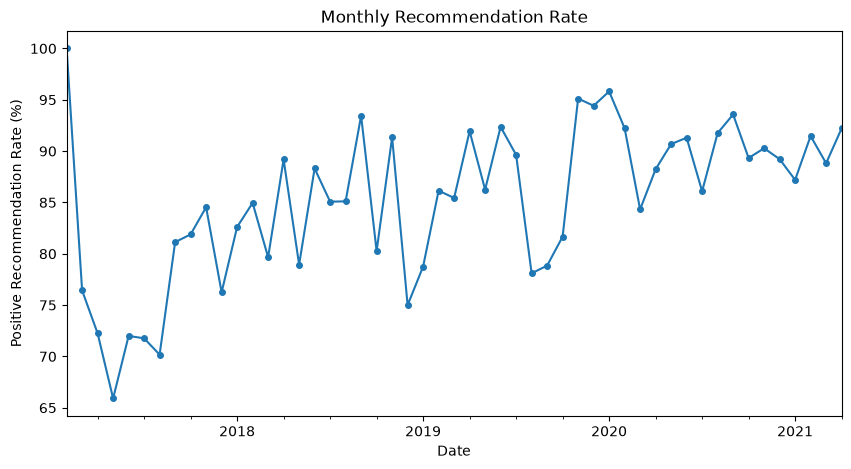

In [36]:
monthly_recommendation = (
    df
    .set_index("created_at")
    .resample("ME")["voted_up"]
    .mean()
    .mul(100)
)

plt.figure(figsize=(10, 5))

monthly_recommendation.plot(marker='o', markersize=4)
plt.xlim(df["created_at"].min(), df["created_at"].max())
plt.title("Monthly Recommendation Rate")
plt.xlabel("Date")
plt.ylabel("Positive Recommendation Rate (%)")

plt.show()

Overall, we can see that the monthly positive recommendation rate experiences a generally upward trend despite its frequent fluctuations.<br>
The very first point in early 2017 sits around ~99% before dropping sharply to ~66%. This means the dataset might have started mid-month with only a handful of reviews, creating an artificial spike.

### 4.6. Key Findings

- **Playtime & Engagement:** Positive recommendations correlate with substantially higher playtime (both at the time of review and overall). Conversely, negative reviews are associated with significantly lower playtime, indicating that critical feedback usually stems from early negative user experiences.
- **Reviewer Profile:** Users who write negative reviews tend to be more active community members on average, possessing higher total game counts and a larger history of written reviews.
- **Review Length & Structure:** Negative reviews are markedly longer than positive ones (median length is more than double), as disgruntled users tend to outline specific criticisms or technical issues in detail.
- **Community Engagement:** Negative reviews receive more upvotes and achieve a higher median helpfulness score (weighted_vote_score), suggesting the community finds critical reviews more constructive when deciding whether to buy a game.
- **Funny Votes Distribution:** The vast majority of reviews—whether positive or negative—receive zero funny votes, making funny votes a sparse metric across the dataset.

## 5. Feature Engineering

### 5.1. Time Features

In [37]:
df["created_year"] = df["created_at"].dt.year
df["created_month"] = df["created_at"].dt.month
df["created_dayofweek"] = df["created_at"].dt.dayofweek

### 5.2. Review Text Features

In [38]:
df["review_length"] = df["review"].str.len()
df["word_count"] = df["review"].str.split().str.len()

### 5.3. Log transformations

In [39]:
import numpy as np

df["log_playtime_forever"] = np.log1p(df["playtime_forever"])
df["log_playtime_at_review"] = np.log1p(df["playtime_at_review"])
df["log_num_games_owned"] = np.log1p(df["num_games_owned"])
df["log_num_reviews"] = np.log1p(df["num_reviews"])
df["log_votes_up"] = np.log1p(df["votes_up"])
df["log_votes_funny"] = np.log1p(df["votes_funny"])

### 5.4. Feature Selection

In [40]:
target = "voted_up"

model_features = ['created_year',
                  'created_month',
                  'created_dayofweek',
                  'log_playtime_at_review',
                  'review_length',
                  'word_count']

# Remove observations with missing review text
model_df = df.dropna(subset=["review"]).copy()

X = model_df[model_features]
y = model_df[target]

Several variables were excluded from predictive modeling because their values may reflect information accumulated after the review was written. Those variables include: log_playtime_forever, log_num_games_owned, log_num_reviews, log_votes_up, and log_votes_funny.

In [41]:
X.isna().sum()

created_year              0
created_month             0
created_dayofweek         0
log_playtime_at_review    0
review_length             0
word_count                0
dtype: int64

## 6. Modeling

We'll add a dummy classifier to evaluate our models' performance against:

In [52]:
from sklearn.dummy import DummyClassifier

dummy_model = DummyClassifier(
    strategy="most_frequent",
    random_state=42
)

dummy_model.fit(X_train, y_train)

y_pred_dummy = dummy_model.predict(X_test)

### 6.1. Train/Test Split

In [53]:
import sklearn
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### 6.2. Logistic Regression

In [54]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[bool](2,)","[False, True]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['created_year','created_month','created_dayofweek', 'log_playtime_at_review','review_length','word_count']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [55]:
y_pred_logistic = logistic_model.predict(X_test)

### 6.3. Decision Tree

In [56]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

### 6.4. Random Forest

In [57]:
from sklearn.ensemble import RandomForestClassifier

forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

forest_model.fit(X_train, y_train)

y_pred_forest = forest_model.predict(X_test)

## 7. Model Evaluation

First we import the required functions:

In [58]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

We'll evaluate the performance of the DummyClassifier:

In [60]:
print("=" * 50)
print("DUMMY CLASSIFIER")
print("=" * 50)

print(f"Accuracy : {accuracy_score(y_test, y_pred_dummy):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dummy, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_dummy):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred_dummy):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dummy))

y_prob_dummy = dummy_model.predict_proba(X_test)[:, 1]
print(f"\nROC-AUC  : {roc_auc_score(y_test, y_prob_dummy):.4f}")

DUMMY CLASSIFIER
Accuracy : 0.8668
Precision: 0.8668
Recall   : 1.0000
F1-score : 0.9286

Confusion Matrix:
[[   0  215]
 [   0 1399]]

ROC-AUC  : 0.5000


### 7.1. Evaluating the Logistic Regression model

In [61]:
print("=" * 50)
print("LOGISTIC REGRESSION")
print("=" * 50)

print(f"Accuracy : {accuracy_score(y_test, y_pred_logistic):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_logistic):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_logistic):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred_logistic):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic))

y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]
print(f"\nROC-AUC  : {roc_auc_score(y_test, y_prob_logistic):.4f}")

LOGISTIC REGRESSION
Accuracy : 0.8674
Precision: 0.8762
Recall   : 0.9864
F1-score : 0.9280

Confusion Matrix:
[[  20  195]
 [  19 1380]]

ROC-AUC  : 0.7107


### 7.2. Evaluating the Decision Tree model

In [62]:
print("=" * 50)
print("DECISION TREE")
print("=" * 50)

print(f"Accuracy : {accuracy_score(y_test, y_pred_tree):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_tree):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_tree):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred_tree):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tree))

y_prob_tree = tree_model.predict_proba(X_test)[:, 1]
print(f"\nROC-AUC  : {roc_auc_score(y_test, y_prob_tree):.4f}")

DECISION TREE
Accuracy : 0.8494
Precision: 0.8778
Recall   : 0.9600
F1-score : 0.9170

Confusion Matrix:
[[  28  187]
 [  56 1343]]

ROC-AUC  : 0.7134


### 7.3. Evaluating the Random Forest model

In [63]:
print("=" * 50)
print("RANDOM FOREST")
print("=" * 50)

print(f"Accuracy : {accuracy_score(y_test, y_pred_forest):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_forest):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_forest):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred_forest):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_forest))

y_prob_forest = forest_model.predict_proba(X_test)[:, 1]
print(f"\nROC-AUC  : {roc_auc_score(y_test, y_prob_forest):.4f}")

RANDOM FOREST
Accuracy : 0.8631
Precision: 0.8800
Recall   : 0.9750
F1-score : 0.9251

Confusion Matrix:
[[  29  186]
 [  35 1364]]

ROC-AUC  : 0.7312


### 7.4. Model Comparison

In [64]:
results = []

models = {
    "Dummy Classifier": (y_pred_dummy, y_prob_dummy),
    "Logistic Regression": (y_pred_logistic, y_prob_logistic),
    "Decision Tree": (y_pred_tree, y_prob_tree),
    "Random Forest": (y_pred_forest, y_prob_forest)
}

for model_name, (y_pred, y_prob) in models.items():
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

comparison_df = pd.DataFrame(results)

comparison_df.round(4)

comparison_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Dummy Classifier,0.866791,0.866791,1.000000,0.928643,0.500000
1,Logistic Regression,0.867410,0.876190,0.986419,0.928043,0.710667
2,Decision Tree,0.849442,0.877778,0.959971,0.917037,0.713412
3,Random Forest,0.863073,0.880000,0.974982,0.925059,0.731217


The three machine learning models achieved relatively similar overall performance. Logistic Regression obtained the highest accuracy (86.74%), recall (98.64%), and F1-score (92.80%), while Random Forest achieved the highest precision (88.00%) and ROC-AUC (0.7312). The Decision Tree produced the lowest accuracy (84.94%) and F1-score (91.70%).

Compared with the Dummy Classifier baseline, the three trained models achieved only a small improvement in accuracy and F1-score. However, their ROC-AUC scores were substantially higher than the baseline value of 0.5000, indicating that the trained models learned some ability to distinguish between positive and negative recommendations.

Among the tested models, Random Forest achieved the highest ROC-AUC and therefore provided the strongest overall discrimination on the test set. However, the differences between the three models were relatively small.

For further investigation of the Random Forest model, we can take a look at its confusion matrix:<br>
[[  29  186]<br>
 [  35 1364]]<br>
There were 215 negative reviews, but the Random Forest correctly identified only 29 of them, which is only about 13.5% of the negative reviews. This means that while having 86.31% accuracy and the highest ROC-AUC, this model is **terrible** at identifying negative recommendations.

## 8. Interpretation & Findings

### 8.1. Key Findings from Exploratory Data Analysis

The exploratory analysis revealed several differences between positive and negative recommendations. Positive recommendations were associated with higher playtime, both at the time of writing the review and overall. In contrast, reviewers who gave negative recommendations tended to have higher levels of overall reviewing activity, including owning more games and writing more reviews.

Negative reviews also tended to be substantially longer than positive reviews. In addition, they generally received more helpful votes and higher helpfulness scores, suggesting that critical reviews may provide information that other users consider useful when evaluating a game. However, these relationships are observational and do not establish causal relationships.

The analysis also revealed a strong class imbalance in the target variable. Approximately 86.7% of the reviews in the sample were positive recommendations, while only 13.3% were negative. This imbalance became particularly important when interpreting the predictive modeling results.

### 8.2. Model Performance

Four classification approaches were evaluated: a Dummy Classifier baseline, Logistic Regression, Decision Tree, and Random Forest.

The three trained models achieved similar overall performance. Logistic Regression obtained the highest accuracy (86.74%), recall (98.64%), and F1-score (92.80%), while Random Forest achieved the highest precision (88.00%) and ROC-AUC (0.7312). The Decision Tree produced the lowest accuracy (84.94%) and F1-score (91.70%).

Random Forest achieved the highest ROC-AUC among the trained models, indicating that it provided the strongest ability to distinguish between positive and negative recommendations based on the selected features. However, the difference between the models was relatively small, suggesting that none of the tested algorithms provided a substantial performance advantage.

### 8.3. Class Imbalance and Model Limitations

Despite the relatively high accuracy and F1-scores, the confusion matrices reveal that all models struggled to identify negative recommendations.

For example, the Random Forest correctly classified only 29 of the 215 negative reviews in the test set. This means that most negative reviews were incorrectly classified as positive. The Dummy Classifier further demonstrates the effect of class imbalance: by simply predicting every review as positive, it achieved 86.68% accuracy and 92.86% F1-score.

Therefore, accuracy and F1-score alone would give an overly optimistic impression of model performance. The ROC-AUC results provide a more informative comparison, as the trained models achieved values substantially above the Dummy Classifier's 0.5000 baseline.

Overall, the models learned some useful patterns from the selected features, but their ability to distinguish negative recommendations remained limited.

### 8.4. Overall Findings

Combining the EDA and modeling results suggests that reviewer behavior and review characteristics are associated with whether a user recommends a game. In particular, playtime at the time of writing the review and basic characteristics of the review text showed differences between positive and negative recommendations.

However, these features alone were not sufficient to produce a highly reliable classification model. The strong class imbalance made negative recommendations particularly difficult to identify, and the relatively modest ROC-AUC scores indicate that additional information would be needed for stronger predictive performance.

These findings also demonstrate the importance of evaluating a classification problem from multiple perspectives. The high accuracy of the models initially appears promising, but comparison with a simple baseline and examination of the confusion matrices reveal important limitations that would not be visible from accuracy alone.

## 9. Limitations & Future Work

This analysis has several limitations. First, the project uses only one sample file containing 8,086 reviews across 12 games, so the findings should not be generalized to all Steam reviews or users.

Second, the target variable is strongly imbalanced toward positive recommendations. Future work could investigate techniques such as class weighting, resampling, or threshold adjustment to improve the identification of negative reviews.

Third, the current modeling approach uses only basic features derived from review metadata, timestamps, playtime at review time, and review length. Although the dataset contains review text, full natural language processing was outside the scope of this project. Future work could incorporate methods such as TF-IDF, sentiment analysis, or transformer-based text representations to investigate whether review content can improve predictive performance.

Finally, the current analysis focuses on associations rather than causal relationships. The observed differences between positive and negative reviews should therefore be interpreted as patterns within this sample rather than evidence that a particular factor directly causes users to recommend or reject a game.

## 10. Conclusion

This project investigated factors associated with whether Steam users recommend a game, using a sample of 8,086 reviews. The analysis examined reviewer playtime, review characteristics, user activity, engagement, and temporal information, followed by classification using Logistic Regression, Decision Tree, and Random Forest models.

The exploratory analysis revealed several notable differences between positive and negative recommendations. Positive recommendations were generally associated with higher playtime, while negative reviews tended to be longer and were written by users with higher overall reviewing activity. Negative reviews also received more helpful votes and higher helpfulness scores on average. These observations suggest that reviewer behavior and review characteristics are associated with recommendation outcomes, although the analysis does not establish causal relationships.

The predictive modeling results showed that the selected features contained some useful information for distinguishing between positive and negative recommendations. Random Forest achieved the highest ROC-AUC of 0.7312, while Logistic Regression achieved the highest accuracy of 86.74%. However, comparison with the Dummy Classifier revealed that the high accuracy and F1-scores were strongly influenced by the substantial class imbalance in the dataset. All models struggled to correctly identify negative recommendations, demonstrating the importance of examining confusion matrices and multiple evaluation metrics rather than relying on accuracy alone.

Overall, the results indicate that basic reviewer and review characteristics can provide some predictive information about recommendation behavior, but they are not sufficient to reliably distinguish between positive and negative reviews in this sample. More advanced approaches, particularly the use of review text through Natural Language Processing, could potentially provide additional information and improve future models.

Finally, this project provided practical experience in the complete data science workflow, including data understanding, data quality assessment, exploratory analysis, feature engineering, model development, evaluation, and interpretation. The findings also demonstrate the importance of considering data limitations, class imbalance, and potential data leakage when building and evaluating machine learning models.